# Task 1: Sales Performance Dashboard
### Kinetrexa Software Pvt. Ltd. — Data Analytics Internship




## Step 1: Install & Import Libraries


In [1]:
!pip install pandas matplotlib seaborn openpyxl -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


## Step 2: Upload Dataset




In [2]:
from google.colab import files
uploaded = files.upload()

print(list(uploaded.keys()))


Saving sales_cleaned.csv to sales_cleaned.csv
['sales_cleaned.csv']


## Step 3: Load the Data




In [4]:

FILENAME = 'sales_cleaned.csv'


df = pd.read_csv(FILENAME, encoding='ISO-8859-1')



print("Shape:", df.shape)
df.head()


Shape: (1007913, 9)


/tmp/ipykernel_1164/696871479.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILENAME, encoding='ISO-8859-1')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
# Check column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1007913 non-null  object 
 1   StockCode    1007913 non-null  object 
 2   Description  1007913 non-null  object 
 3   Quantity     1007913 non-null  int64  
 4   InvoiceDate  1007913 non-null  object 
 5   Price        1007913 non-null  float64
 6   Customer ID  779425 non-null   float64
 7   Country      1007913 non-null  object 
 8   Revenue      1007913 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 69.2+ MB


## Step 4: Data Cleaning



In [6]:

df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:


rename_map = {
    'InvoiceNo': 'Invoice',
    'UnitPrice': 'Price',
    'CustomerID': 'Customer ID'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

print(df.columns.tolist())


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']


In [9]:

df = df[~df['Invoice'].astype(str).str.startswith('C')]


df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df = df.drop_duplicates()


df['Revenue'] = df['Quantity'] * df['Price']

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (1007913, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [10]:

df.to_csv('sales_cleaned.csv', index=False)

from google.colab import files
files.download('sales_cleaned.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 5: Core KPIs

In [11]:
total_revenue = df['Revenue'].sum()
total_orders = df['Invoice'].nunique()
total_customers = df['Customer ID'].nunique() if 'Customer ID' in df.columns else None
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
if total_customers:
    print(f"Total Unique Customers: {total_customers:,}")
print(f"Average Order Value: £{avg_order_value:,.2f}")


Total Revenue: £20,476,260.45
Total Orders: 40,079
Total Unique Customers: 5,878
Average Order Value: £510.90


## Step 6: Revenue Trend Over Time

/tmp/ipykernel_1164/2339724295.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.set_index('InvoiceDate').resample('M')['Revenue'].sum()


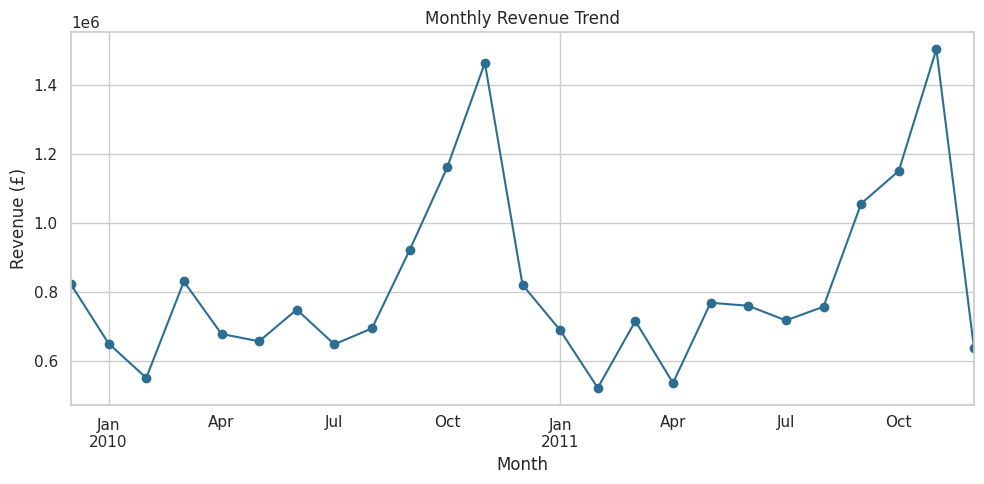

In [12]:
monthly_revenue = df.set_index('InvoiceDate').resample('M')['Revenue'].sum()

plt.figure()
monthly_revenue.plot(kind='line', marker='o', color='#2c6e91')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=150)
plt.show()


## Step 7: Top 10 Products by Revenue

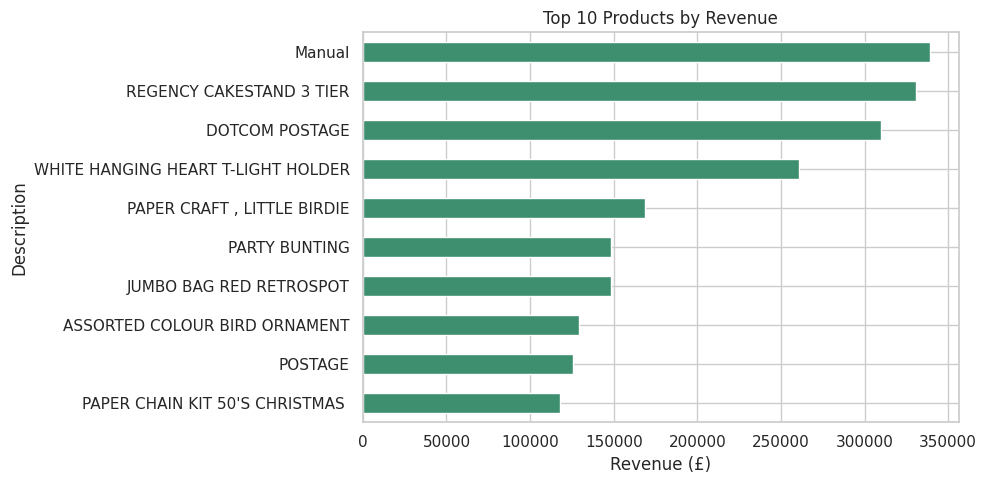

,Revenue
Description,
Manual,339241.29
REGENCY CAKESTAND 3 TIER,330590.32
DOTCOM POSTAGE,309854.11
WHITE HANGING HEART T-LIGHT HOLDER,260990.22
"PAPER CRAFT , LITTLE BIRDIE",168469.60
PARTY BUNTING,148318.28
JUMBO BAG RED RETROSPOT,148073.47
ASSORTED COLOUR BIRD ORNAMENT,129324.49
POSTAGE,125682.42


In [13]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.sort_values().plot(kind='barh', color='#3d8f6f')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

top_products


## Step 8: Regional (Country-wise) Sales

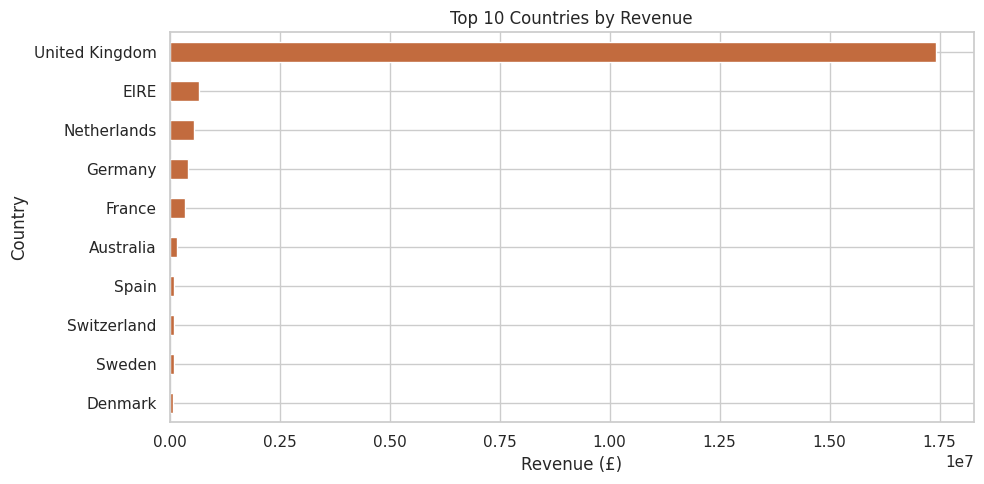

,Revenue
Country,
United Kingdom,1.741020e+07
EIRE,6.587673e+05
Netherlands,5.540381e+05
Germany,4.250197e+05
France,3.504561e+05
Australia,1.692835e+05
Spain,1.083325e+05
Switzerland,1.006856e+05
Sweden,9.186982e+04


In [14]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
country_revenue.sort_values().plot(kind='barh', color='#c26b3e')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('country_revenue.png', dpi=150)
plt.show()

country_revenue


## Step 9: Customer Purchasing Behavior

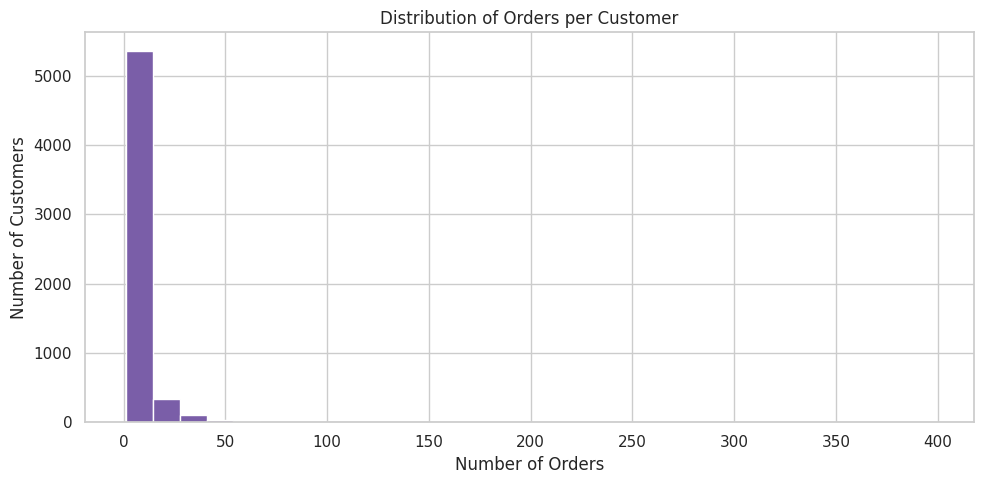

Repeat customers: 4255
One-time customers: 1623


In [15]:
if 'Customer ID' in df.columns:
    orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique()

    plt.figure()
    orders_per_customer.plot(kind='hist', bins=30, color='#7a5ea8')
    plt.title('Distribution of Orders per Customer')
    plt.xlabel('Number of Orders')
    plt.ylabel('Number of Customers')
    plt.tight_layout()
    plt.savefig('orders_per_customer.png', dpi=150)
    plt.show()

    repeat_customers = (orders_per_customer > 1).sum()
    one_time_customers = (orders_per_customer == 1).sum()
    print(f"Repeat customers: {repeat_customers}")
    print(f"One-time customers: {one_time_customers}")


## Step 10: Download All Charts



In [16]:
from google.colab import files
for fname in ['revenue_trend.png', 'top_products.png', 'country_revenue.png', 'orders_per_customer.png']:
    try:
        files.download(fname)
    except Exception as e:
        print(f"Could not download {fname}: {e}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>